In [ ]:
#Demo, compute error and plots,  no fits  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, OptimizeWarning
import h5py


In [ ]:
OFFS = [0, .03125, .0625, .09375] # the offset for the sliding bin 
SNAP_Z = {9:5.,13:4.,17:3.,37:2.,47:1.5,57:1.,62:.75,67:.5,69:.4,71:.3,73:.2,75:.1,77:0.} 
'''
- `Jet`
- `Jet_fgas-4sigma`
- `Mstar-1sigma`
- `Mstar-1sigma_fgas-4sigma`
- `fgas+2sigma`
- `fgas-2sigma`
- `fgas-4sigma`
- `fgas-8sigma`
''' 

In [317]:
# Read in raw profiles v3 
PATH = "/Users/jpaine/Desktop/Flamingo/"
# PATH = "/path/to/your/folder/"   # 
f = h5py.File(f"{PATH}profiles_v3.hdf5", "r")

# snapshot number (13 snaps), each holding one group per 8 sims 
# each sim holds one group per 0.125-dex mass-bin chunk 
# containing per halo dmo/hyd profiles (m_dmo/m_hyd)
# OT displacement (ot) per average histograms, and the averages histograms 

print(list(f.keys()), list(f["77"].keys()), list(f["77"]["Jet"].keys())[:3],
      list(f["77"]["Jet"][list(f["77"]["Jet"].keys())[0]].keys()))


['13', '17', '37', '47', '57', '62', '67', '69', '71', '73', '75', '77', '9'] ['Jet', 'Jet_fgas-4sigma', 'Mstar-1sigma', 'Mstar-1sigma_fgas-4sigma', 'fgas+2sigma', 'fgas-2sigma', 'fgas-4sigma', 'fgas-8sigma'] ['10.000_10.125', '10.125_10.250', '10.250_10.375'] ['avg_dmo', 'avg_hyd', 'cnt_dmo', 'cnt_hyd', 'dmo_m200', 'dmo_r200', 'edges', 'has_dmo', 'has_hyd', 'hyd_m200', 'hyd_r200', 'm_dmo', 'm_hyd', 'npart_dmo', 'npart_hyd', 'ot', 'rc']


In [318]:
# for the sliding bins, I recommputed the OT maps 
W = 0.125   # mass-window width (dex)
slides = {}
slides[0]       = pd.read_csv(f"{PATH}slide_avg_hist_0.00000.csv", dtype={"snap": str})
slides[.03125]  = pd.read_csv(f"{PATH}slide_avg_hist_0.03125.csv", dtype={"snap": str})
slides[.0625]   = pd.read_csv(f"{PATH}slide_avg_hist_0.06250.csv", dtype={"snap": str})
slides[.09375]  = pd.read_csv(f"{PATH}slide_avg_hist_0.09375.csv", dtype={"snap": str})


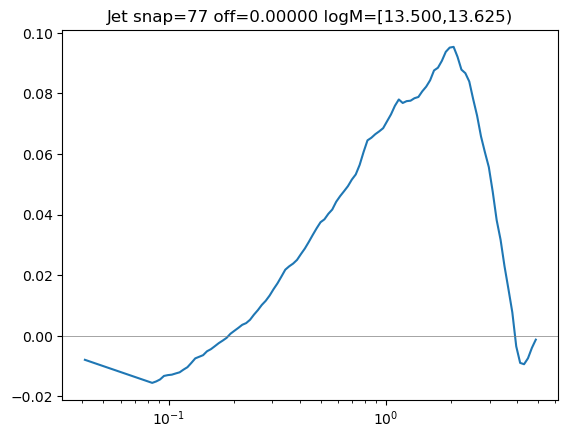

In [319]:
# plot the sliding bins 
def plot_bin(sim, snap, off, mass):
    d = slides[off]; d = d[(d.snap == snap) & (d.sim == sim)]
    lo = d.logM_lo.iloc[(d.logM_lo - mass).abs().values.argmin()]
    b = d[np.isclose(d.logM_lo, lo)].sort_values("rc")
    plt.plot(b.rc, b.ot_disp, "-")   # no error band yet -- bootstrap not read in yet
    plt.xscale("log"); plt.axhline(0, color="gray", lw=.5)
    plt.title(f"{sim} snap={snap} off={off:.5f} logM=[{lo:.3f},{lo+W:.3f})")
    plt.show()

plot_bin("Jet", "77", OFFS[0], 13.5)


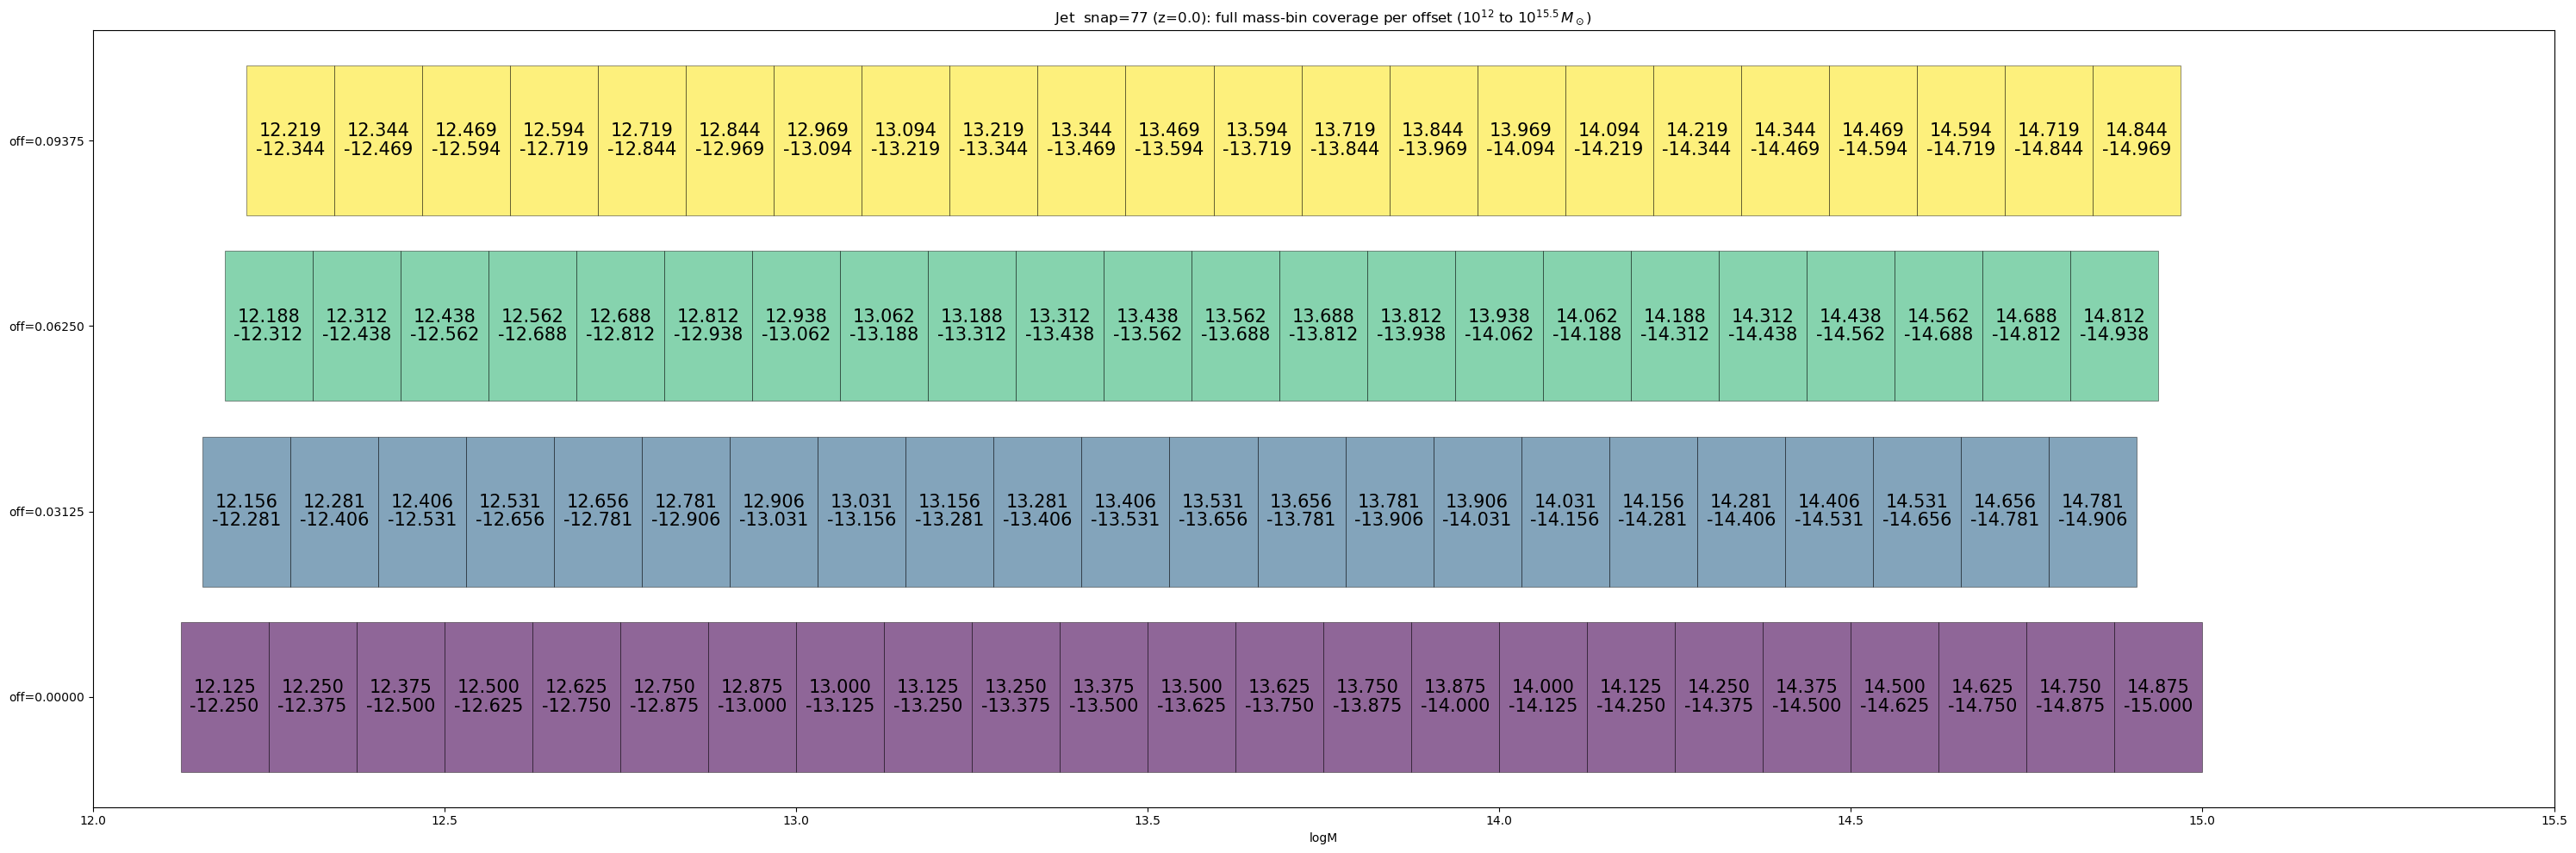

In [320]:
# colored mass-bin coverage plot -- one row per slide/offset, rectangles show each bin's
# [logM_lo, logM_hi) range, so you can see how much the 4 slides overlap
def plot_bin_coverage_wide(sim, snap):
    fig, ax = plt.subplots(figsize=(30, 10))
    cmap_off = plt.cm.viridis(np.linspace(0, 1, len(OFFS)))
    row_gap = 1.3
    bar_h = 1.05
    for row, (off, c) in enumerate(zip(OFFS, cmap_off)):
        y0 = row * row_gap
        dd = slides[off]
        exx = dd[(dd.snap == snap) & (dd.sim == sim)]
        edges = sorted(exx.logM_lo.unique())
        bars = [(e, W) for e in edges]
        ax.broken_barh(bars, (y0 - bar_h/2, bar_h), facecolors=c, edgecolors="k", alpha=.6, lw=.5)
        for e in edges:
            ax.text(e + W/2, y0, f"{e:.3f}\n-{e+W:.3f}", ha="center", va="center",
                    fontsize=15, rotation=0, linespacing=1.1)
    ax.set_yticks([row * row_gap for row in range(len(OFFS))])
    ax.set_yticklabels([f"off={off:.5f}" for off in OFFS])
    ax.set_xlim(12, 15.5)
    ax.set_xlabel("logM")
    z = SNAP_Z.get(int(snap), np.nan)
    ax.set_title(f"{sim}  snap={snap} (z={z}): full mass-bin coverage per offset "
                 r"($10^{12}$ to $10^{15.5}\,M_\odot$)")
    plt.tight_layout(); plt.show()

plot_bin_coverage_wide("Jet", "77")


In [321]:
# compare two overlapping bins (different slides) and count halos shared between them
def shared_halos(sim, snap, lo, hi):
    grp = f[snap][sim]
    n = 0
    for k in grp:
        c_lo, c_hi = (float(x) for x in k.split("_"))
        if c_hi <= lo or c_lo >= hi:
            continue
        g = grp[k]
        mm = np.log10(g["dmo_m200"][:])
        n += int(np.sum((mm >= lo) & (mm < hi) & g["has_dmo"][:] & g["has_hyd"][:]))
    return n


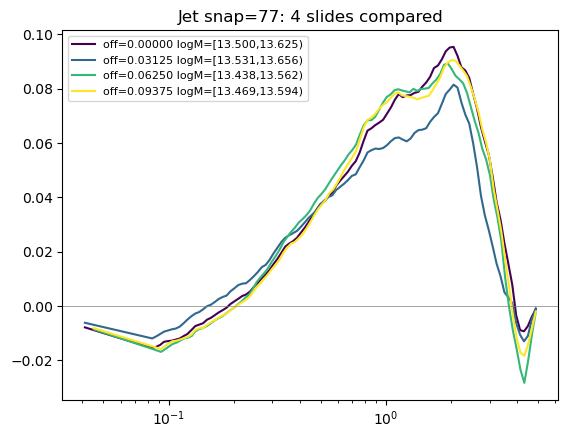

off=0.00000 & off=0.03125: 714 halos shared
off=0.03125 & off=0.06250: 255 halos shared
off=0.06250 & off=0.09375: 774 halos shared


In [322]:
# compare slide 
def plot_compare_slides(sim, snap, mass, offs=OFFS):
    bins = []
    for off in offs:
        d = slides[off]; d = d[(d.snap == snap) & (d.sim == sim)]
        lo = d.logM_lo.iloc[(d.logM_lo - mass).abs().values.argmin()]
        b = d[np.isclose(d.logM_lo, lo)].sort_values("rc")
        bins.append((off, lo, b))

    for j, (off, lo, b) in enumerate(bins):
        c = plt.cm.viridis(j / max(len(bins)-1, 1))
        plt.plot(b.rc, b.ot_disp, "-", color=c, label=f"off={off:.5f} logM=[{lo:.3f},{lo+W:.3f})")
    plt.xscale("log"); plt.axhline(0, color="gray", lw=.5)
    plt.legend(fontsize=8)
    plt.title(f"{sim} snap={snap}: {len(bins)} slides compared")
    plt.show()

    for (off_a, lo_a, _), (off_b, lo_b, _) in zip(bins[:-1], bins[1:]):
        n = shared_halos(sim, snap, max(lo_a, lo_b), min(lo_a, lo_b) + W)
        print(f"off={off_a:.5f} & off={off_b:.5f}: {n} halos shared")

plot_compare_slides("Jet", "77", 13.5, offs=OFFS)        # all 4 slides



In [323]:
# Read in the bootstrap error,  computed by resampling halos 
def add_rank(df):
    df = df.sort_values(["snap", "sim", "logM_lo", "rc"]).copy()
    df["_rank"] = df.groupby(["snap", "sim", "logM_lo"]).cumcount()
    return df

def merge_boot(slide_df, boot_df):
    a = add_rank(slide_df)
    b = add_rank(boot_df)[["snap", "sim", "logM_lo", "_rank", "ot_disp_std"]]
    return a.drop(columns=["ot_disp_std"]).merge(
        b, on=["snap", "sim", "logM_lo", "_rank"], how="left").drop(columns=["_rank"])

boot0 = pd.read_csv(f"{PATH}slide1_boot_a19.csv", dtype={"snap": str})
boot1 = pd.read_csv(f"{PATH}slide2_boot_a19.csv", dtype={"snap": str})
boot2 = pd.read_csv(f"{PATH}slide3_boot_a19.csv", dtype={"snap": str})
boot3 = pd.read_csv(f"{PATH}slide4_boot_a19.csv", dtype={"snap": str})

slides[0]      = merge_boot(slides[0], boot0)
slides[.03125] = merge_boot(slides[.03125], boot1)
slides[.0625]  = merge_boot(slides[.0625], boot2)
slides[.09375] = merge_boot(slides[.09375], boot3)


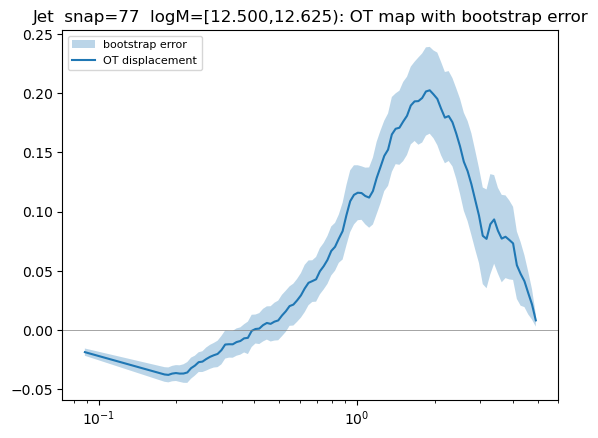

In [324]:
# one example OT map with  bootstrap 
d = slides[0]; d = d[(d.snap == "77") & (d.sim == "Jet")]
lo = sorted(d.logM_lo.unique())[3]
b = d[np.isclose(d.logM_lo, lo)].sort_values("rc")
plt.fill_between(b.rc, b.ot_disp - b.ot_disp_std, b.ot_disp + b.ot_disp_std, alpha=.3,
                  label="bootstrap error")
plt.plot(b.rc, b.ot_disp, "-", label="OT displacement")
plt.xscale("log"); plt.axhline(0, color="gray", lw=.5)
plt.legend(fontsize=8)
plt.title(f"Jet  snap=77  logM=[{lo:.3f},{lo+W:.3f}): OT map with bootstrap error")
plt.show()


In [325]:
def plot_mass_neighbors(sim, snap, off, n=5, mass=None, end="low"):
    off_idx = OFFS.index(off) if off in OFFS else int(np.argmin(np.abs(np.array(OFFS) - off)))
    c = plt.cm.viridis(off_idx / max(len(OFFS)-1, 1))

    d = slides[off]; d = d[(d.snap == snap) & (d.sim == sim)]
    los_all = np.array(sorted(d.logM_lo.unique()))
    if mass is not None:
        idx = int(np.argmin(np.abs(los_all - mass)))
        los = los_all[idx:idx+n] if end == "high" else los_all[max(0, idx-n+1):idx+1]
    else:
        los = los_all[-n:] if end == "high" else los_all[:n]

    fig, ax = plt.subplots(1, len(los), figsize=(4*len(los), 3.5), sharey=True)
    ax = np.atleast_1d(ax)
    for j, lo in enumerate(los):
        b = d[np.isclose(d.logM_lo, lo)].sort_values("rc")
        ax[j].fill_between(b.rc, b.ot_disp - b.ot_disp_std, b.ot_disp + b.ot_disp_std,
                            color=c, alpha=.3)
        ax[j].plot(b.rc, b.ot_disp, "-", color=c)
        ax[j].set_xscale("log"); ax[j].axhline(0, color="gray", lw=.5)
        ax[j].set_title(f"logM=[{lo:.3f},{lo+W:.3f})", fontsize=9)
    plt.suptitle(f"{sim}  snap={snap}  off={off:.5f}: {len(los)} neighboring mass bins", y=1.03)
    plt.tight_layout(); plt.show()


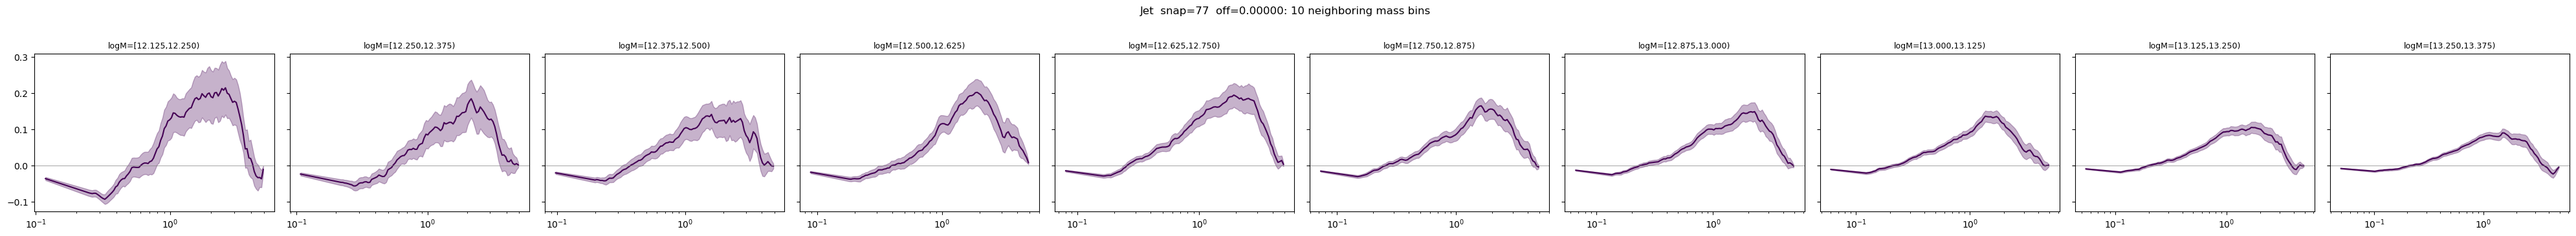

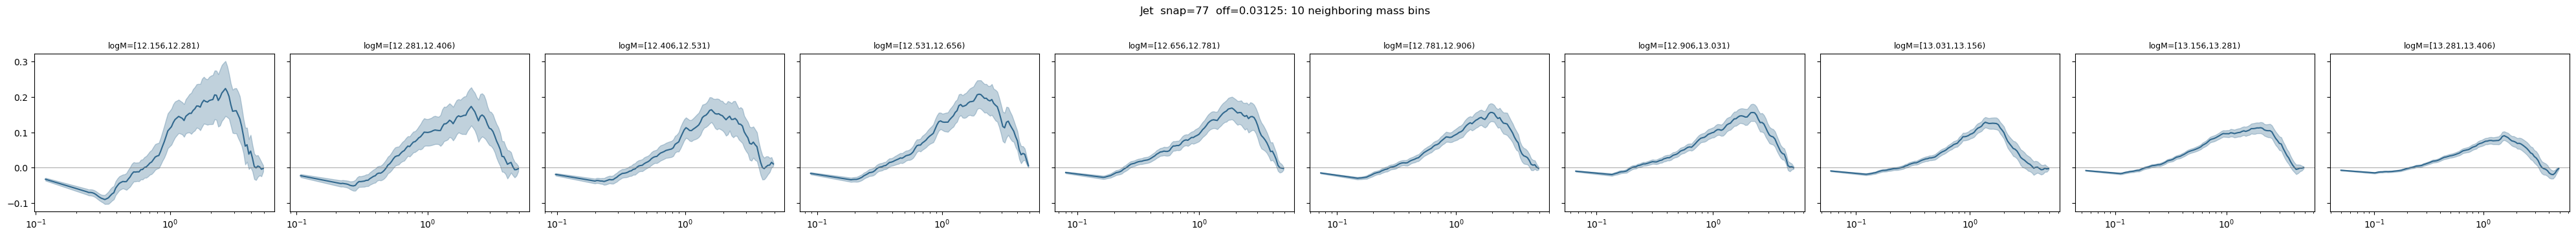

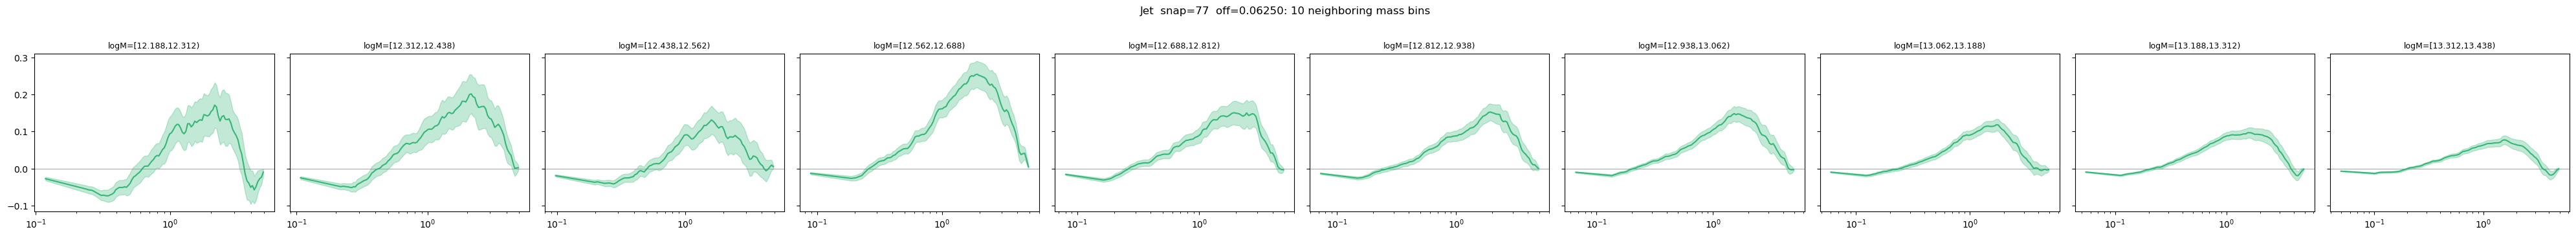

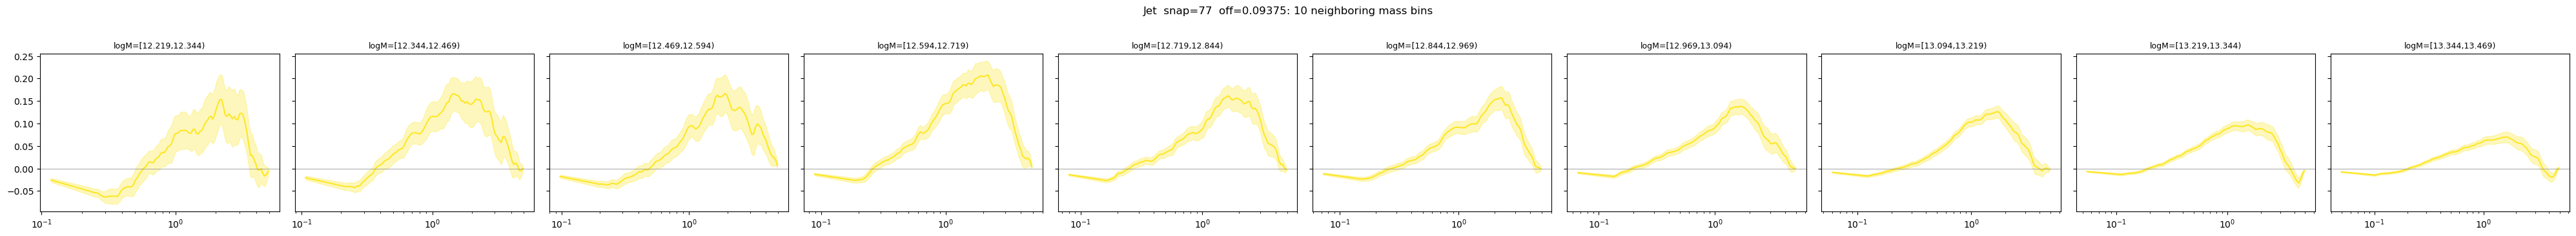

In [ ]:
sim = "Jet"   # <-- edit this to plot a different sim
for off in OFFS:
    plot_mass_neighbors(sim, "77", off, n=10,end="low")

 # amp of OT map decrease and mass increase, looks pretty linearly    


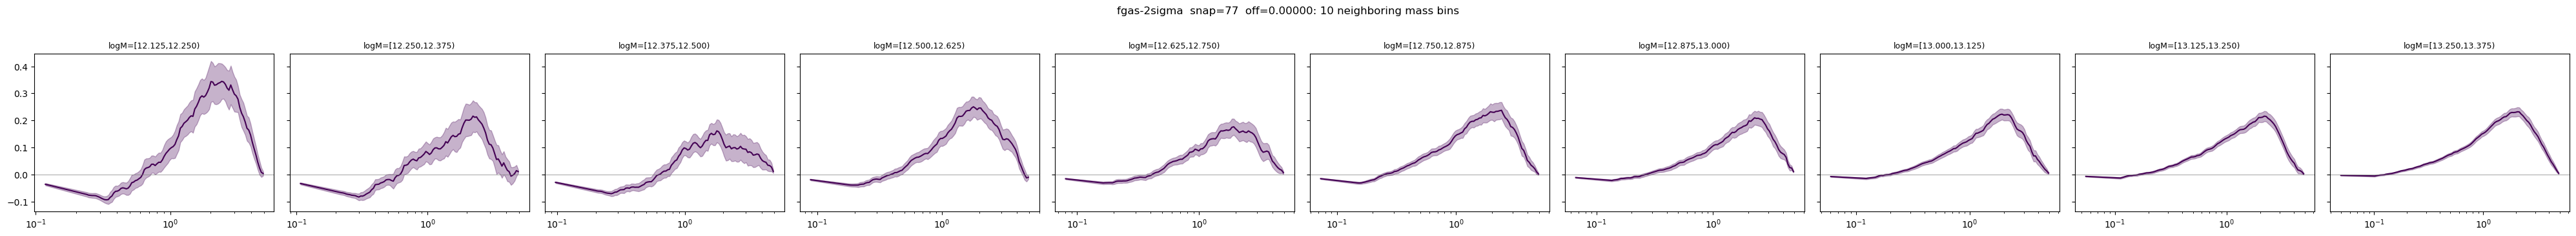

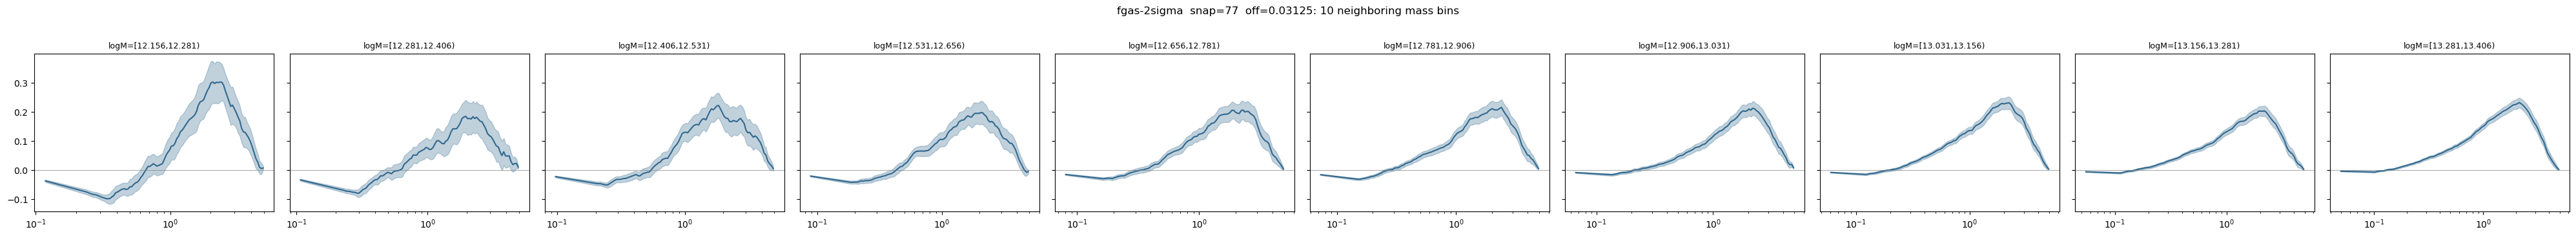

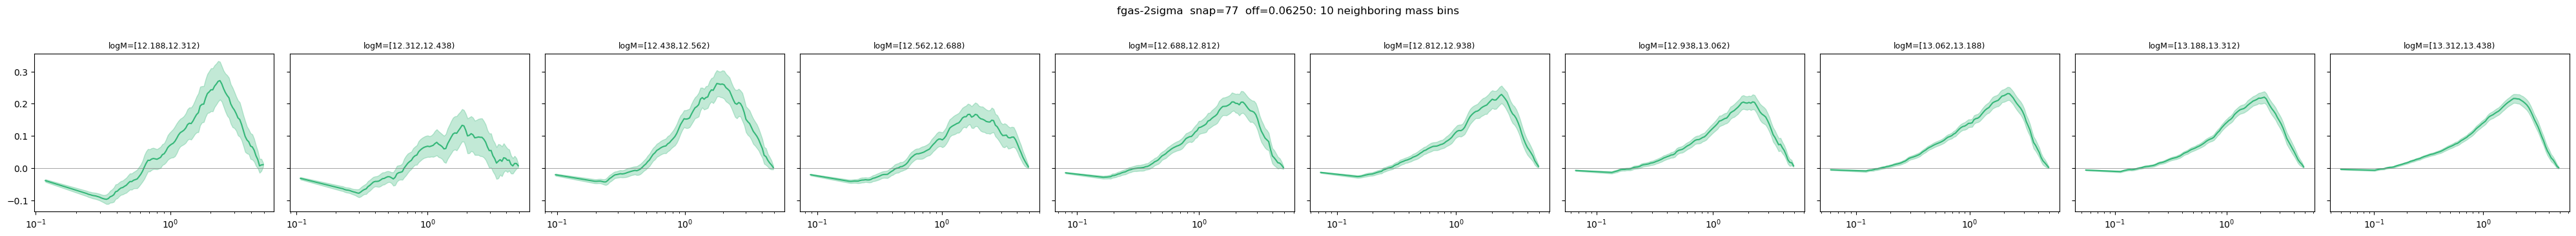

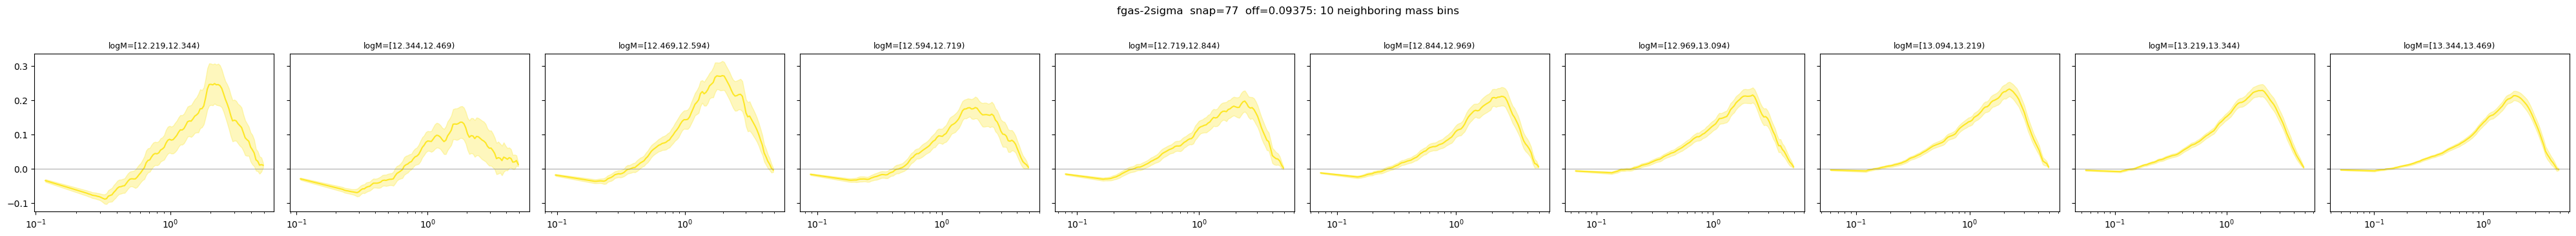

In [335]:
for off in OFFS:
    plot_mass_neighbors("fgas-2sigma", "77", off, n=10,end="low")


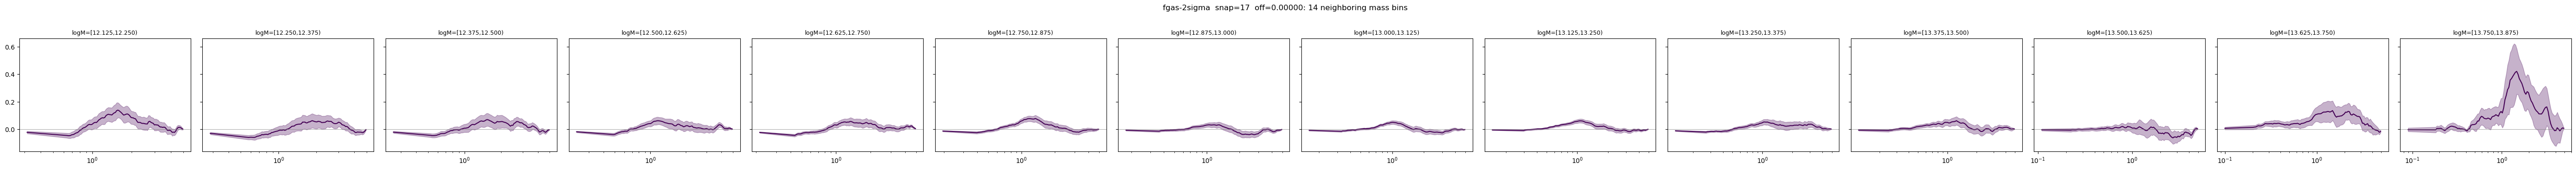

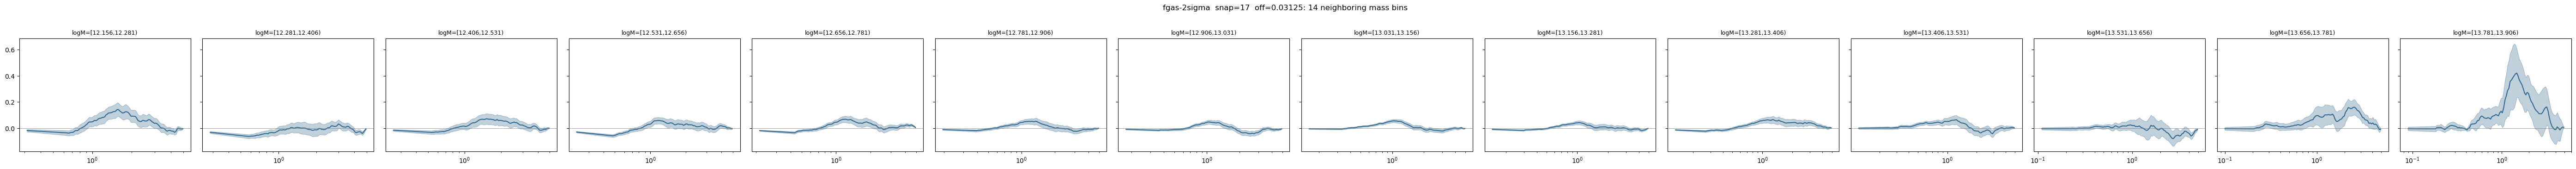

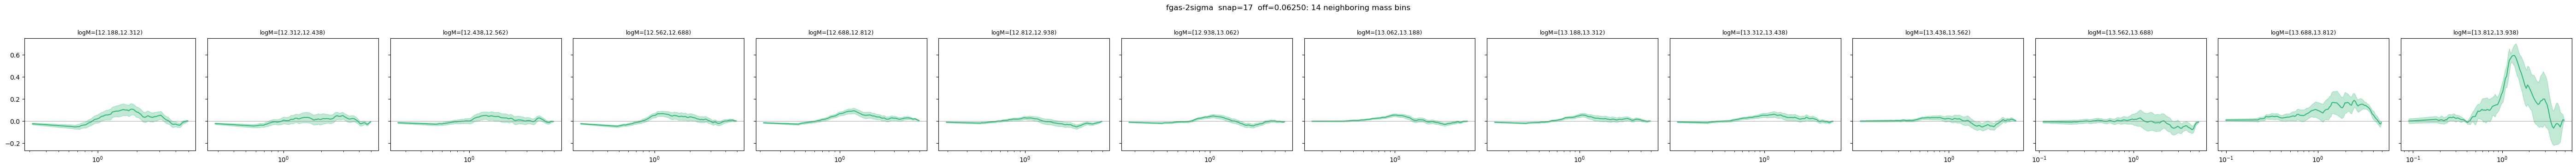

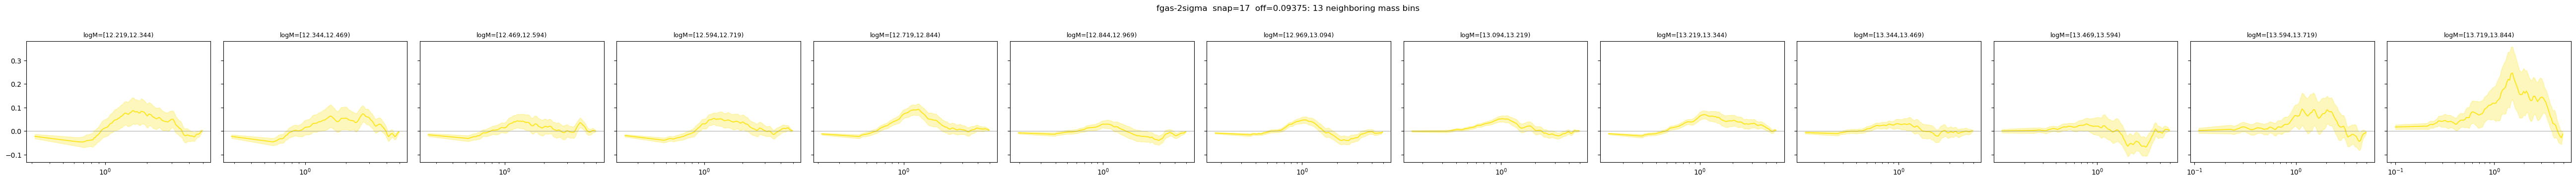

In [ ]:
for off in OFFS:
    plot_mass_neighbors("fgas-2sigma", "17", off, n=40,end="high")
    

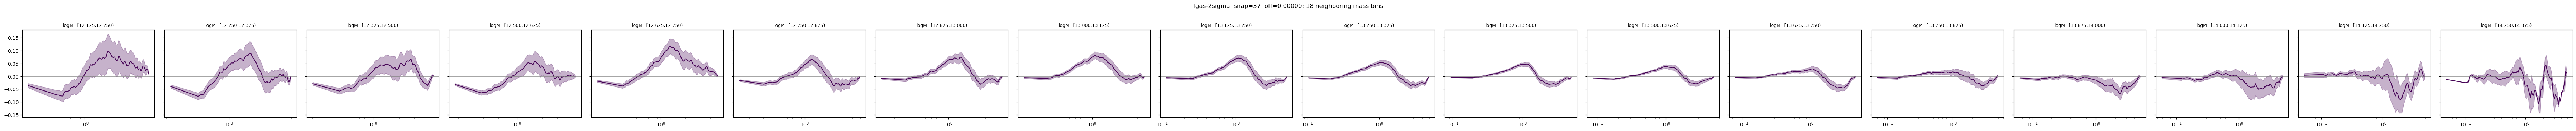

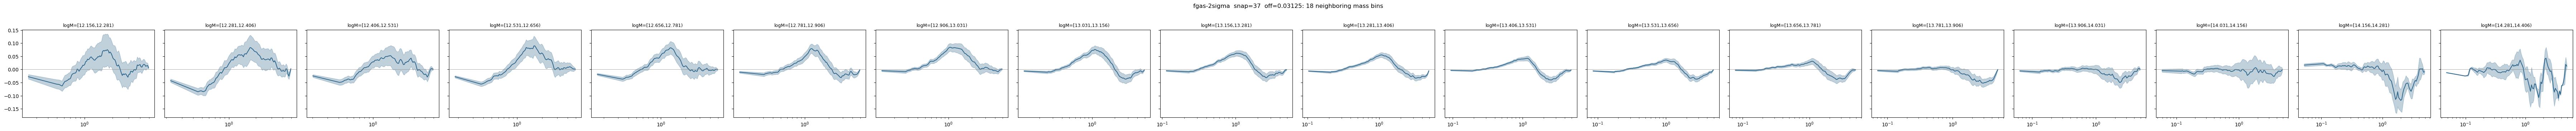

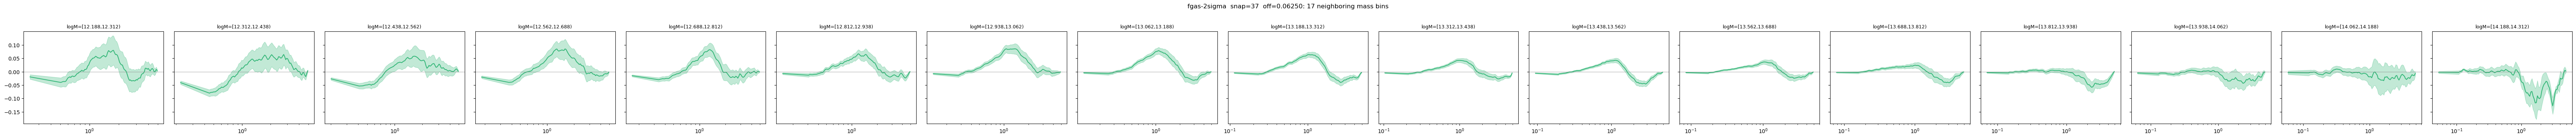

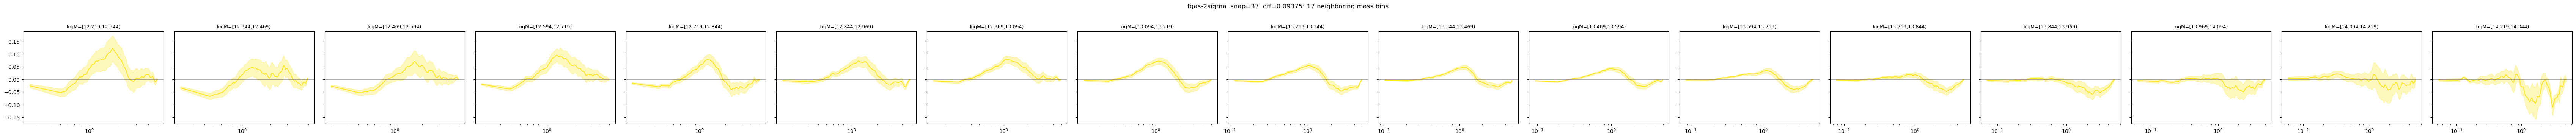

In [337]:
for off in OFFS:
    plot_mass_neighbors("fgas-2sigma", "37", off, n=40,end="high")

In [327]:
# last time I computed this based on the not smoothest of PCA maps, but I think this
#  just on the OT maps is better and the error is smaller
# the none smoothness in the m,z space is great that OT map varince so good to know 

In [328]:
# now to compute the per bin varaince to add to the error
# interpolate each of the 4 offsets' own closest-bin curve onto a common r-grid, then the
# std across those 4 curves at each r is the binning sigma. 



def bin_and_total_error(sim, snap, mass):
    grid = np.geomspace(0.06, 5.0, 100)
    curves = []
    for off in OFFS:
        d = slides[off]; d = d[(d.snap == snap) & (d.sim == sim)]
        lo = d.logM_lo.iloc[(d.logM_lo - mass).abs().values.argmin()]
        b = d[np.isclose(d.logM_lo, lo)].sort_values("rc")
        curves.append(np.interp(grid, b.rc, b.ot_disp))
    bin_std = np.array(curves).std(axis=0)

    d0 = slides[OFFS[0]]; d0 = d0[(d0.snap == snap) & (d0.sim == sim)]
    lo0 = d0.logM_lo.iloc[(d0.logM_lo - mass).abs().values.argmin()]
    b0 = d0[np.isclose(d0.logM_lo, lo0)].sort_values("rc")
    y = np.interp(grid, b0.rc, b0.ot_disp)
    boot_std = np.interp(grid, b0.rc, b0.ot_disp_std)
    total_std = np.sqrt(boot_std**2 + bin_std**2)
    return grid, y, boot_std, bin_std, total_std


def plot_bin_total_error(sim, snap, mass):
    grid, y, boot_std, bin_std, total_std = bin_and_total_error(sim, snap, mass)
    plt.fill_between(grid, y-total_std, y+total_std, alpha=.25, label="total (bootstrap+binning)")
    plt.fill_between(grid, y-boot_std, y+boot_std, alpha=.35, label="bootstrap only")
    plt.plot(grid, y, "k-", label="OT displacement")
    plt.xscale("log"); plt.axhline(0, color="gray", lw=.5)
    plt.legend(fontsize=8)
    plt.title(f"{sim}  snap={snap}  logM~{mass}: bootstrap-only vs total error")
    plt.show()
    print(f"median boot_std={np.median(boot_std):.4f}  bin_std={np.median(bin_std):.4f}  "
          f"total_std={np.median(total_std):.4f}")


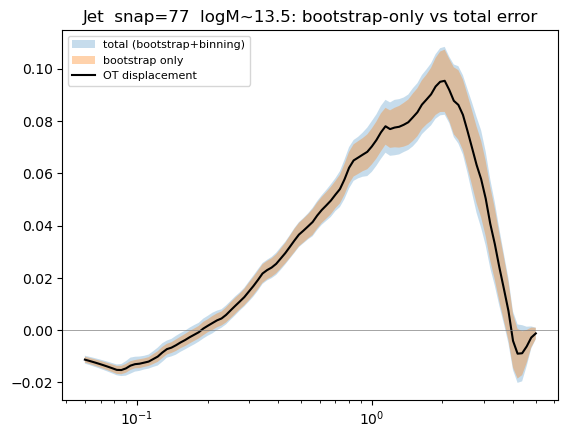

median boot_std=0.0045  bin_std=0.0028  total_std=0.0048


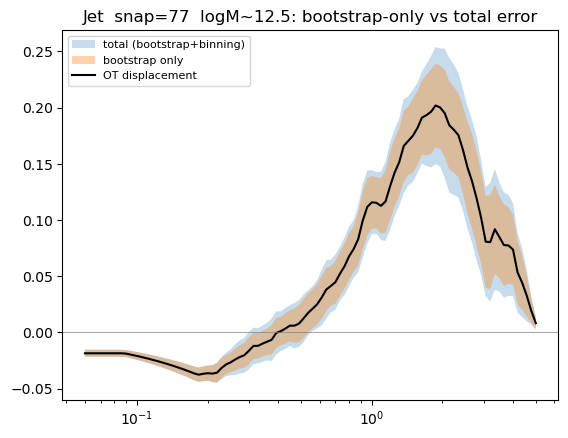

median boot_std=0.0168  bin_std=0.0126  total_std=0.0201


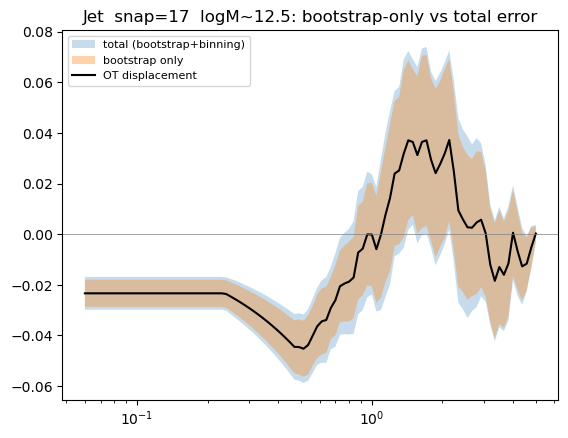

median boot_std=0.0107  bin_std=0.0074  total_std=0.0131


In [329]:
# See worse at lower mass and higher z 

plot_bin_total_error("Jet", "77", 13.5)
plot_bin_total_error("Jet", "77", 12.5)
plot_bin_total_error("Jet", "17", 12.5)



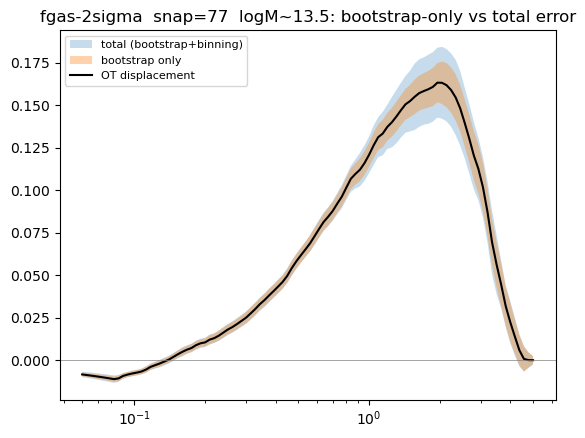

median boot_std=0.0044  bin_std=0.0015  total_std=0.0045


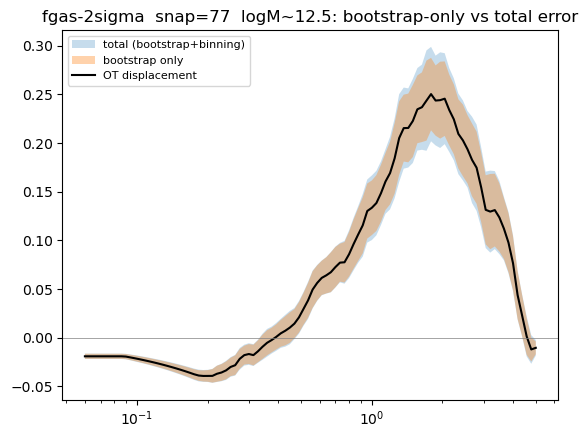

median boot_std=0.0161  bin_std=0.0057  total_std=0.0173


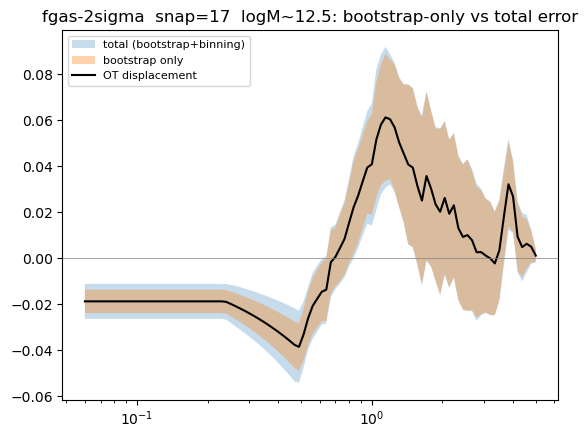

median boot_std=0.0105  bin_std=0.0056  total_std=0.0143


In [330]:
plot_bin_total_error("fgas-2sigma", "77", 13.5)
plot_bin_total_error("fgas-2sigma", "77", 12.5)
plot_bin_total_error("fgas-2sigma", "17", 12.5)

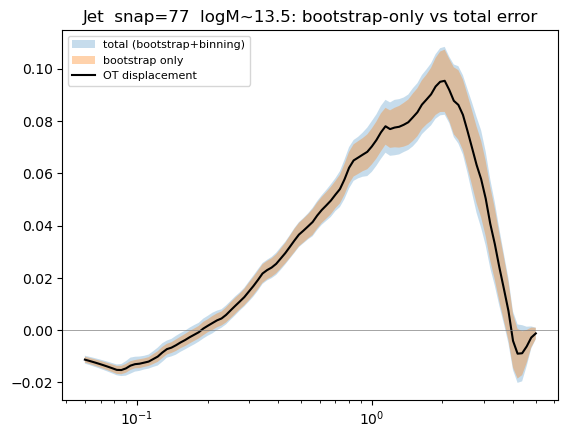

median boot_std=0.0045  bin_std=0.0028  total_std=0.0048


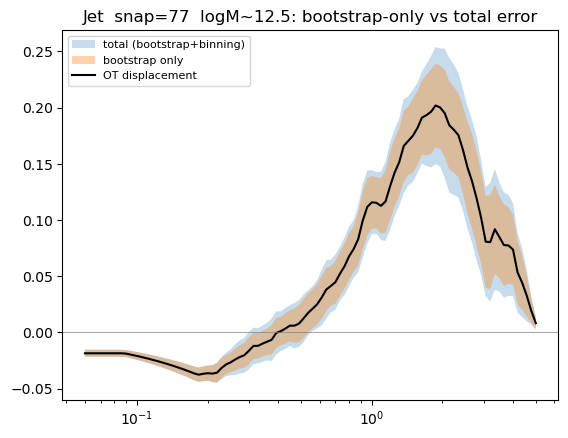

median boot_std=0.0168  bin_std=0.0126  total_std=0.0201


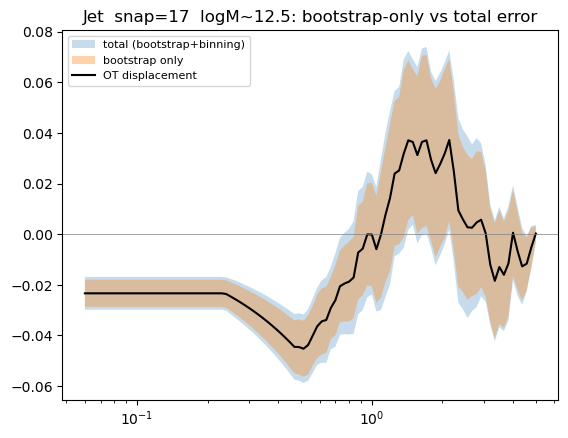

median boot_std=0.0107  bin_std=0.0074  total_std=0.0131


In [331]:

plot_bin_total_error("Jet", "77", 13.5)
plot_bin_total_error("Jet", "77", 12.5)
plot_bin_total_error("Jet", "17", 12.5)

In [ ]:
# trends: peak amplitude vs mass, and peak amplitude vs z -- so the "peak decreases as
# mass increases" pattern seen panel-by-panel above is an actual plotted trend, not just eyeballed
def plot_peak_vs_mass(sim, snap, n=10, end="low"):
    for off in OFFS:
        off_idx = OFFS.index(off)
        c = plt.cm.viridis(off_idx / max(len(OFFS)-1, 1))
        d = slides[off]; d = d[(d.snap == snap) & (d.sim == sim)]
        los_all = np.array(sorted(d.logM_lo.unique()))
        los = los_all[-n:] if end == "high" else los_all[:n]
        peaks = [np.abs(d[np.isclose(d.logM_lo, lo)].ot_disp).max() for lo in los]
        plt.plot(los + W/2, peaks, "o-", color=c, label=f"off={off:.5f}")
    plt.xlabel("logM"); plt.ylabel("peak |OT displacement|")
    plt.legend(fontsize=8)
    plt.title(f"{sim}  snap={snap}: peak amplitude vs mass, all 4 slides")
    plt.show()

def plot_peak_vs_z(sim, mass):
    snaps = [s for s in sorted(SNAP_Z, key=SNAP_Z.get) if SNAP_Z[s] <= 3]
    for off in OFFS:
        off_idx = OFFS.index(off)
        c = plt.cm.viridis(off_idx / max(len(OFFS)-1, 1))
        zs, peaks = [], []
        for sn in snaps:
            d = slides[off]; d = d[(d.snap == str(sn)) & (d.sim == sim)]
            if len(d) == 0:
                continue
            lo = d.logM_lo.iloc[(d.logM_lo - mass).abs().values.argmin()]
            b = d[np.isclose(d.logM_lo, lo)]
            zs.append(SNAP_Z[sn]); peaks.append(np.abs(b.ot_disp).max())
        plt.plot(zs, peaks, "o-", color=c, label=f"off={off:.5f}")
    plt.xlabel("z"); plt.ylabel("peak |OT displacement|")
    plt.legend(fontsize=8)
    plt.title(f"{sim}  logM~{mass}: peak amplitude vs z, all 4 slides")
    plt.show()

plot_peak_vs_mass("Jet", "77", n=10, end="low")
plot_peak_vs_z("Jet", 13.0)


In [ ]:
# same peak-amplitude trends, now one line per SIM instead of per slide (one fixed slide,
# off=OFFS[0] by default, so the comparison is sim-to-sim not offset-to-offset)
sims = ["Jet", "Jet_fgas-4sigma", "Mstar-1sigma", "Mstar-1sigma_fgas-4sigma",
        "fgas+2sigma", "fgas-2sigma", "fgas-4sigma", "fgas-8sigma"]

def plot_peak_vs_mass_allsims(snap, off=OFFS[0], n=None, end="low"):
    for i, sim in enumerate(sims):
        c = plt.cm.tab10(i)
        d = slides[off]; d = d[(d.snap == snap) & (d.sim == sim)]
        los_all = np.array(sorted(d.logM_lo.unique()))
        los = los_all if n is None else (los_all[-n:] if end == "high" else los_all[:n])
        peaks = [np.abs(d[np.isclose(d.logM_lo, lo)].ot_disp).max() for lo in los]
        plt.plot(los + W/2, peaks, "o-", color=c, label=sim)
    plt.xlabel("logM"); plt.ylabel("peak |OT displacement|")
    plt.legend(fontsize=7)
    plt.title(f"snap={snap}  off={off:.5f}: peak amplitude vs mass, all sims")
    plt.show()

def plot_peak_vs_z_allsims(mass, off=OFFS[0]):
    snaps = [s for s in sorted(SNAP_Z, key=SNAP_Z.get) if SNAP_Z[s] <= 3]
    for i, sim in enumerate(sims):
        c = plt.cm.tab10(i)
        zs, peaks = [], []
        for sn in snaps:
            d = slides[off]; d = d[(d.snap == str(sn)) & (d.sim == sim)]
            if len(d) == 0:
                continue
            lo = d.logM_lo.iloc[(d.logM_lo - mass).abs().values.argmin()]
            b = d[np.isclose(d.logM_lo, lo)]
            zs.append(SNAP_Z[sn]); peaks.append(np.abs(b.ot_disp).max())
        plt.plot(zs, peaks, "o-", color=c, label=sim)
    plt.xlabel("z"); plt.ylabel("peak |OT displacement|")
    plt.legend(fontsize=7)
    plt.title(f"logM~{mass}  off={off:.5f}: peak amplitude vs z, all sims")
    plt.show()

plot_peak_vs_mass_allsims("77")           # n=None -> full mass range (all bins for each sim)
plot_peak_vs_z_allsims(13.0)              # already full z range (every real snapshot, z<=3)


In [ ]:
# r/R200c location of each zero crossing of the OT displacement curve (0th, 1st, 2nd, 3rd --
# most curves have 1-2, but track up to 4 in case a curve wiggles more), vs mass and vs z, one
# line per offset (same viridis-by-offset convention as the other trend plots)
def find_zero_crossings(r, y):
    sign = np.sign(y)
    idx = np.where(np.diff(sign) != 0)[0]
    crossings = []
    for i in idx:
        r0, r1, y0, y1 = r[i], r[i+1], y[i], y[i+1]
        crossings.append(r0 - y0 * (r1 - r0) / (y1 - y0))
    return crossings

def plot_zero_crossings_vs_mass(sim, snap, off=OFFS[0], n=None, end="low"):
    d = slides[off]; d = d[(d.snap == snap) & (d.sim == sim)]
    los_all = np.array(sorted(d.logM_lo.unique()))
    los = los_all if n is None else (los_all[-n:] if end == "high" else los_all[:n])
    masses = los + W/2
    by_idx = {k: [] for k in range(4)}
    for lo in los:
        b = d[np.isclose(d.logM_lo, lo)].sort_values("rc")
        crossings = find_zero_crossings(b.rc.values, b.ot_disp.values)
        for k in range(4):
            by_idx[k].append(crossings[k] if k < len(crossings) else np.nan)
    for k in range(4):
        plt.plot(masses, by_idx[k], "o-", label=f"zero #{k}")
    plt.xlabel("logM"); plt.ylabel(r"$r/R_{200c}$ of zero crossing")
    plt.yscale("log"); plt.legend(fontsize=8)
    plt.title(f"{sim}  snap={snap}  off={off:.5f}: zero-crossing locations vs mass")
    plt.show()

def plot_zero_crossings_vs_z(sim, mass, off=OFFS[0]):
    snaps = [s for s in sorted(SNAP_Z, key=SNAP_Z.get) if SNAP_Z[s] <= 3]
    zs = []
    by_idx = {k: [] for k in range(4)}
    for sn in snaps:
        d = slides[off]; d = d[(d.snap == str(sn)) & (d.sim == sim)]
        if len(d) == 0:
            continue
        lo = d.logM_lo.iloc[(d.logM_lo - mass).abs().values.argmin()]
        b = d[np.isclose(d.logM_lo, lo)].sort_values("rc")
        crossings = find_zero_crossings(b.rc.values, b.ot_disp.values)
        zs.append(SNAP_Z[sn])
        for k in range(4):
            by_idx[k].append(crossings[k] if k < len(crossings) else np.nan)
    for k in range(4):
        plt.plot(zs, by_idx[k], "o-", label=f"zero #{k}")
    plt.xlabel("z"); plt.ylabel(r"$r/R_{200c}$ of zero crossing")
    plt.yscale("log"); plt.legend(fontsize=8)
    plt.title(f"{sim}  logM~{mass}  off={off:.5f}: zero-crossing locations vs z")
    plt.show()

plot_zero_crossings_vs_mass("Jet", "77")   # n=None -> full mass range
plot_zero_crossings_vs_z("Jet", 13.0)


In [ ]:
# self-similarity check -- rescale each curve by ITS OWN peak height and peak location
# (r/R200c where |OT displacement| is largest), then overlay curves spanning a wide M,z range.
# If they collapse onto one common shape, the curve is self-similar and a much simpler model
# (peak height(M,z) + peak location(M,z) + one fixed template shape) could replace the full
# 14-parameter PCA model. If they DON'T collapse, the shape itself changes with M,z, not just
# its scale, and this simpler approach won't work.
def plot_self_similar_check(sim, off=OFFS[0], targets=None):
    if targets is None:
        targets = [("77", 12.5), ("77", 13.5), ("77", 14.5),
                   ("57", 12.5), ("57", 13.5), ("57", 14.5),
                   ("37", 13.0), ("17", 12.5), ("17", 13.0), ("17", 13.5)]
    cmap = plt.cm.viridis(np.linspace(0, 1, len(targets)))
    for (snap, mass), c in zip(targets, cmap):
        d = slides[off]; d = d[(d.snap == snap) & (d.sim == sim)]
        if len(d) == 0:
            continue
        lo = d.logM_lo.iloc[(d.logM_lo - mass).abs().values.argmin()]
        b = d[np.isclose(d.logM_lo, lo)].sort_values("rc")
        r, y = b.rc.values, b.ot_disp.values
        i_peak = np.argmax(np.abs(y))
        r_peak, y_peak = r[i_peak], y[i_peak]
        if r_peak == 0 or y_peak == 0:
            continue
        z = SNAP_Z[int(snap)]
        plt.plot(r / r_peak, y / y_peak, "-", color=c, label=f"logM={lo+W/2:.2f} z={z:.2f}")
    plt.axhline(0, color="gray", lw=.5)
    plt.axhline(1, color="gray", lw=.3, ls="--")
    plt.axvline(1, color="gray", lw=.3, ls="--")
    plt.xlabel(r"$r / r_{peak}$"); plt.ylabel("OT displacement / peak")
    plt.xscale("log")
    plt.legend(fontsize=7)
    plt.title(f"{sim}  off={off:.5f}: rescaled curves (self-similarity check)")
    plt.show()

plot_self_similar_check("Jet")


In [ ]:
# where in (logM, z) does the curve have 1, 2, 3, or 4+ zero crossings? scatter colored by
# exact count (blue/green/yellow/red), plus a fitted boundary line between the "1-2" and "3+"
# regions (a straight line in logM vs z, fit through each z's transition mass).
def crossing_count_map(sim, off=OFFS[0]):
    d_all = slides[off]; d_all = d_all[d_all.sim == sim]
    snaps = [s for s in sorted(SNAP_Z, key=SNAP_Z.get) if SNAP_Z[s] <= 3]
    rows = []
    for sn in snaps:
        dd = d_all[d_all.snap == str(sn)]
        for lo in sorted(dd.logM_lo.unique()):
            b = dd[np.isclose(dd.logM_lo, lo)].sort_values("rc")
            n = len(find_zero_crossings(b.rc.values, b.ot_disp.values))
            rows.append((lo + W/2, SNAP_Z[sn], n))
    return pd.DataFrame(rows, columns=["logM", "z", "n_cross"])

def plot_crossing_count_map(sim, off=OFFS[0]):
    df = crossing_count_map(sim, off)
    color_map = {1: "blue", 2: "green", 3: "gold"}

    fig, ax = plt.subplots(figsize=(7, 5.5))
    for n, c in color_map.items():
        sel = df.n_cross == n
        ax.scatter(df.logM[sel], df.z[sel], c=c, s=25, label=f"{n} zero" + ("s" if n > 1 else ""))
    sel4 = df.n_cross >= 4
    ax.scatter(df.logM[sel4], df.z[sel4], c="red", s=25, label="4+ zeros")

    # fit a boundary: for each z, the smallest mass where the count is already 3+
    boundary = []
    for z in sorted(df.z.unique()):
        sub = df[df.z == z].sort_values("logM")
        if sub.n_cross.le(2).any() and sub.n_cross.ge(3).any():
            boundary.append((z, sub.logM[sub.n_cross >= 3].min()))

    if len(boundary) >= 2:
        zs, ms = zip(*boundary)
        coef = np.polyfit(zs, ms, deg=1)
        z_line = np.linspace(0, 3, 50)
        m_line = np.polyval(coef, z_line)
        ax.plot(m_line, z_line, "k--", lw=2, label="1-2 vs 3+ boundary")

    ax.set_xlabel("logM"); ax.set_ylabel("z")
    ax.invert_yaxis()
    ax.legend(fontsize=8)
    ax.set_title(f"{sim}  off={off:.5f}: zero-crossing count regions")
    plt.tight_layout(); plt.show()

plot_crossing_count_map("Jet")
